# 📊 Schema-RAG Execution Accuracy Evaluation

**Pipeline:** Question → Gemini extracts filters → ChromaDB retrieves schema docs → Gemini generates SQL → Validator checks → Supabase executes → Compare results

This notebook measures whether the generated SQL returns the **exact same data** as the expected SQL.

In [1]:
# Install dependencies
!pip install chromadb psycopg2-binary google-genai groq python-dotenv pandas matplotlib sqlglot pydantic -q
print("✅ Dependencies installed")


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✅ Dependencies installed


In [2]:
# Upload your schema-rag-eval folder as a zip
# OR if using VS Code Colab extension, mount your local files
import os

# Option A: Upload zip (uncomment if needed)
# from google.colab import files
# import zipfile
# uploaded = files.upload()
# zip_name = list(uploaded.keys())[0]
# with zipfile.ZipFile(zip_name, "r") as z:
#     z.extractall(".")

# Option B: If files are already accessible (VS Code Colab extension)
# Set this to your schema-rag-eval directory path
WORK_DIR = "/content/schema-rag-eval"  # Change this if needed

# If running from VS Code with local files, copy them to Colab
import shutil
LOCAL_DIR = "/Users/ragavhariharan/Projects/EarthTekniks-Internship/schema-rag-eval"

# For VS Code Colab: upload the needed files manually or use the cell below
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Working directory: {os.getcwd()}")
print(f"Files: {os.listdir(".") if os.path.exists(".") else "empty"}")

OSError: [Errno 30] Read-only file system: '/content'

## 🔑 Configuration

Set your credentials below. **Recommended:** Use Colab Secrets panel (🔑 icon) instead of hardcoding.

Get a free Gemini API key at: https://aistudio.google.com/apikey

In [4]:
import os

# Check if running in Google Colab
IS_COLAB = "COLAB_RELEASE_TAG" in os.environ or os.path.exists("/content")

if IS_COLAB:
    # ── Colab environment: Use Colab Secrets (🔑 icon on the left panel) ──
    from google.colab import userdata
    os.environ["DB_HOST"] = userdata.get("DB_HOST")
    os.environ["DB_PORT"] = userdata.get("DB_PORT")
    os.environ["DB_NAME"] = userdata.get("DB_NAME")
    os.environ["DB_USER"] = userdata.get("DB_USER")
    os.environ["DB_PASSWORD"] = userdata.get("DB_PASSWORD")
    os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("✅ Credentials loaded from Colab Secrets")
else:
    # ── Local environment: Load from local .env file ──
    from dotenv import load_dotenv
    load_dotenv()  # Reads .env in this folder
    print("✅ Credentials loaded from local .env file")

print(f"   DB Host: {os.environ.get('DB_HOST', 'NOT SET')[:30]}...")
print(f"   Gemini:  {'Set' if os.environ.get('GEMINI_API_KEY') else 'NOT SET'}")
print(f"   Groq:    {'Set' if os.environ.get('GROQ_API_KEY') else 'NOT SET'}")

✅ Credentials loaded from local .env file
   DB Host: aws-1-ap-south-1.pooler.supaba...
   Gemini:  Set
   Groq:    Set


## 📁 Upload Project Files

Upload your project files from VS Code. Run this cell, then upload:
- 
- 
- 
-  folder (as a zip named )
- 
- 

In [ ]:
from google.colab import files as colab_files
import zipfile, os

print("Upload your project files (schema_registry.json, golden_dataset.json, sql_validator.py, generate_chunks.py, ingest_chroma.py, docs.zip):")
uploaded = colab_files.upload()

# Extract docs.zip if uploaded
if "docs.zip" in uploaded:
    with zipfile.ZipFile("docs.zip", "r") as z:
        z.extractall(".")
    print("✅ docs/ extracted")

print(f"Files in directory: {os.listdir(".")}")
if os.path.exists("docs"):
    print(f"Docs files: {os.listdir("docs")}")

In [5]:
# Build ChromaDB index from documentation
!python generate_chunks.py
!python ingest_chroma.py

import chromadb
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_collection("lens_schema_rag")
print(f"✅ ChromaDB: {collection.count()} chunks indexed")

Scanning 18 documentation files in docs/...

  ✅ accessories_documentation.md: 4 table(s)
  ✅ antivibration_documentation.md: 1 table(s)
  ✅ autofocus_documentation.md: 1 table(s)
  ✅ fa_documentation.md: 1 table(s)
  ✅ inspection_documentation.md: 1 table(s)
  ✅ large_format_autofocus_documentation.md: 1 table(s)
  ✅ large_format_documentation.md: 1 table(s)
  ✅ laser_coaxial_documentation.md: 1 table(s)
  ✅ line_scan_documentation.md: 9 table(s)
  ✅ m12_mount_documentation.md: 1 table(s)
  ✅ macro_documentation.md: 1 table(s)
  ✅ magnifying_documentation.md: 1 table(s)
  ✅ microscope_documentation.md: 1 table(s)
  ✅ motorized_bi_telecentric_documentation.md: 1 table(s)
  ✅ spectral_documentation.md: 1 table(s)
  ✅ telecentric_documentation.md: 4 table(s)
  ✅ three_cmos_documentation.md: 1 table(s)
  ✅ zoom_documentation.md: 1 table(s)

────────────────────────────────────────────────────────────
Total chunks generated: 32
  accessory..................... 4 table(s)
  anti_vibration..

In [6]:
# Test database connection
import psycopg2, pandas as pd, warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

DB_CONFIG = {
    "host": os.environ["DB_HOST"],
    "port": os.environ.get("DB_PORT", "6543"),
    "dbname": os.environ.get("DB_NAME", "postgres"),
    "user": os.environ["DB_USER"],
    "password": os.environ["DB_PASSWORD"],
    "options": "-c search_path=ragav",
}

try:
    conn = psycopg2.connect(**DB_CONFIG, connect_timeout=15)
    conn.set_session(readonly=True, autocommit=True)
    df = pd.read_sql_query("SELECT COUNT(*) as cnt FROM fa_lenses;", conn)
    conn.close()
    print(f"✅ Database connected! FA lenses table has {df.iloc[0]['cnt']} rows.")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Database connected! FA lenses table has 63 rows.


## 🚀 Run Full Evaluation

This cell runs the complete pipeline for all 25 queries and shows a live trace with retrieved tables, filters, SQL, and pass/fail.

In [6]:
import json, re, time, os, warnings
from collections import Counter
from datetime import datetime
import chromadb, pandas as pd, psycopg2
from groq import Groq

warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

# ══════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════

GROQ_MODEL = "llama-3.1-8b-instant"
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# If running in Google Colab, also try to retrieve from userdata secrets
IS_COLAB = "COLAB_RELEASE_TAG" in os.environ or os.path.exists("/content")
if IS_COLAB:
    from google.colab import userdata
    for var in ["DB_HOST", "DB_PORT", "DB_NAME", "DB_USER", "DB_PASSWORD", "GEMINI_API_KEY", "GROQ_API_KEY"]:
        try:
            val = userdata.get(var)
            if val:
                os.environ[var] = val
        except Exception:
            pass

USE_OLLAMA = True  # Set to False to use Groq instead
OLLAMA_MODEL = "qwen3-coder:480b-cloud"

groq_client = None
if not USE_OLLAMA:
    groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

DB_CONFIG = {
    "host": os.environ["DB_HOST"],
    "port": os.environ.get("DB_PORT", "6543"),
    "dbname": os.environ.get("DB_NAME", "postgres"),
    "user": os.environ["DB_USER"],
    "password": os.environ["DB_PASSWORD"],
    "options": "-c search_path=ragav",
}

chroma_client = chromadb.PersistentClient(path="./chroma_db")
collection = chroma_client.get_collection(name="lens_schema_rag")

from sql_validator import SQLValidator
validator = SQLValidator()

VALID_PRODUCT_TYPES = {
    "line_scan", "fa_lens", "telecentric", "macro", "large_format",
    "zoom", "microscope", "spectral", "three_cmos", "m12_mount",
    "anti_vibration", "autofocus", "laser_coaxial", "inspection", "accessory",
}

# ══════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════

def execute_sql_safely(sql):
    conn = None
    try:
        conn = psycopg2.connect(**DB_CONFIG, connect_timeout=15)
        conn.set_session(readonly=True, autocommit=True)
        df = pd.read_sql_query(sql, conn)
        return df, None
    except Exception as e:
        return None, str(e)
    finally:
        if conn:
            try: conn.close()
            except: pass

def gemini_call(system_prompt, user_prompt, json_mode=False):
    if USE_OLLAMA:
        import ollama
        kwargs = {}
        if json_mode:
            kwargs["format"] = "json"
        
        max_retries = 3
        for attempt in range(max_retries):
            try:
                response = ollama.chat(
                    model=OLLAMA_MODEL,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    options={"temperature": 0, "num_ctx": 8192},
                    **kwargs
                )
                return response["message"]["content"]
            except Exception as e:
                if attempt < max_retries - 1:
                    time.sleep(1)
                else:
                    raise e
    else:
        import random
        config = {"temperature": 0}
        if json_mode:
            config["response_format"] = {"type": "json_object"}
        
        max_retries = 6
        base_delay = 2.0
        for attempt in range(max_retries):
            try:
                response = groq_client.chat.completions.create(
                    model=GROQ_MODEL,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    **config
                )
                return response.choices[0].message.content
            except Exception as e:
                err_str = str(e).lower()
                is_rate_limit = "429" in err_str or "rate_limit" in err_str or "rate limit" in err_str
                if is_rate_limit and attempt < max_retries - 1:
                    delay = base_delay * (2.0 ** attempt) + random.uniform(0.1, 1.0)
                    print(f"\n⚠️ Groq Rate Limit (429) encountered. Retrying in {delay:.2f} seconds... (Attempt {attempt + 1}/{max_retries})")
                    time.sleep(delay)
                elif attempt < max_retries - 1:
                    delay = base_delay + random.uniform(0.1, 1.0)
                    print(f"\n⚠️ API error encountered: {e}. Retrying in {delay:.2f} seconds... (Attempt {attempt + 1}/{max_retries})")
                    time.sleep(delay)
                else:
                    raise e
def extract_sql_from_text(text):
    m = re.search(r"```sql\s*(.*?)\s*```", text, re.DOTALL | re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```\s*(.*?)\s*```", text, re.DOTALL)
    if m: return m.group(1).strip()
    return text.strip()

def llm_extract_filters(user_query):
    system_prompt = """You are a metadata filter extractor for an industrial machine vision lens catalog.
Extract metadata filters as JSON:
{
  "product_type": string or null,
  "resolution_target": string or null,
  "pixel_pitch_um": number or null,
  "is_coaxial": true/false or null,
  "is_new_series": true/false or null
}
PRODUCT TYPE MAPPING:
- "line_scan" for line scan lens
- "fa_lens" for FA/factory automation lens
- "telecentric" for telecentric lens
- "macro" for macro/close-up lens
- "large_format" for large format lens
- "zoom" for zoom lens
- "microscope" for microscope/magnifying lens
- "spectral" for spectral/SWIR/NIR lens
- "three_cmos" for 3-CMOS/prism lens
- "m12_mount" for M12/board/S-mount lens
- "anti_vibration" for anti-vibration lens
- "autofocus" for autofocus/AF lens
- "laser_coaxial" for laser coaxial lens
- "inspection" for 360/cylindrical inspection
- "accessory" for adapter/extension ring/focusing ring/lens holder
Return ONLY JSON. Use null if unsure."""
    try:
        raw = gemini_call(system_prompt, user_query, json_mode=True)
        parsed = json.loads(raw)
    except:
        parsed = {}
    filters = {k: None for k in ["product_type","resolution_target","pixel_pitch_um","is_coaxial","is_new_series"]}
    if parsed.get("product_type") and parsed["product_type"] in VALID_PRODUCT_TYPES:
        filters["product_type"] = parsed["product_type"]
    if parsed.get("resolution_target"):
        val = str(parsed["resolution_target"]).upper().replace(" ","")
        if not val.endswith("K"): val += "K"
        filters["resolution_target"] = val
    if parsed.get("pixel_pitch_um") is not None:
        try: filters["pixel_pitch_um"] = float(parsed["pixel_pitch_um"])
        except: pass
    if isinstance(parsed.get("is_coaxial"), bool): filters["is_coaxial"] = parsed["is_coaxial"]
    if isinstance(parsed.get("is_new_series"), bool): filters["is_new_series"] = parsed["is_new_series"]
    # Post-extraction cleanup: Line Scan fields only exist on line_scan chunks
    if filters["product_type"] is not None and filters["product_type"] != "line_scan":
        filters["resolution_target"] = None
        filters["pixel_pitch_um"] = None
        filters["is_coaxial"] = None
        filters["is_new_series"] = None
    return filters

def run_pipeline(user_query):
    filters = llm_extract_filters(user_query)
    search_params = {"query_texts": [user_query], "n_results": 3}
    conds = []
    if filters.get("product_type"): conds.append({"product_type": filters["product_type"]})
    if filters.get("resolution_target"): conds.append({"resolution_target": filters["resolution_target"]})
    if filters.get("pixel_pitch_um") is not None: conds.append({"pixel_pitch_um": filters["pixel_pitch_um"]})
    if filters.get("is_coaxial") is True: conds.append({"is_coaxial": True})
    if filters.get("is_new_series") is True: conds.append({"is_new_series": True})
    if conds:
        search_params["where"] = {"$and": conds} if len(conds) > 1 else conds[0]
    results = collection.query(**search_params)
    contexts = results["documents"][0] if results["documents"] else []
    retrieved_tables = [m.get("table_name","?") for m in results["metadatas"][0]] if results["metadatas"][0] else []
    system_prompt = f"""You are an expert PostgreSQL engineer for an industrial machine vision company.
Convert the user request into a flawless SQL query.
RULES:
1. Base your query ONLY on the SCHEMA CONTEXT below.
2. Do not hallucinate column names.
3. Output ONLY raw SQL. No markdown, no explanations.
4. Always include model_name in SELECT.
5. SELECT only relevant columns.
SUPERLATIVE QUERIES: Return the model record, not aggregate. Filter NULLs.
Example: \"cheapest?\" -> SELECT model_name, list_price FROM [table] WHERE list_price IS NOT NULL ORDER BY list_price ASC LIMIT 1;
ENGINEERING GLOSSARY:
- \"Widest/Maximum Aperture\" or \"Fastest\" -> f_no_min (lower = wider)
- \"Minimum Aperture\" -> f_no_max
- \"Warping\"/\"distortion\" -> tv_distortion_percent
- \"Working distance\"/\"standoff\" -> wd_mm (or wd_min_mm/wd_max_mm)
- \"Telecentricity\" -> telecentricity_degrees
- \"DOF\" -> dof_mm
- \"NA\"/\"numerical aperture\" -> numerical_aperture
- \"Sensor size\" -> sensor_size_raw
- \"Megapixel\" -> megapixel_rating
- \"MOD\" -> mod_distance_m
- \"Wavelength\" -> wavelength_min_nm / wavelength_max_nm
- \"Response time\" -> response_time_ms
- \"Adapter\" -> mount_primary_raw, mount_secondary_raw
- \"uniformity\" / \"edge brightness\" -> relative_illuminance_percent
CROSS-TABLE: Use UNION ALL. No semicolons between SELECTs.
SCHEMA CONTEXT:
{chr(10).join(contexts)}"""
    clean_sql = ""
    for attempt in range(3):
        raw = gemini_call(system_prompt, user_query)
        clean_sql = extract_sql_from_text(raw)
        val = validator.validate(clean_sql)
        if val.is_valid:
            break
        if attempt < 2:
            user_query = f"""SQL failed validation. Bad SQL:
{clean_sql}
Error: {val.reason}
Fix it. Output only corrected raw SQL."""
            print(f"  [Self-Heal] Attempt {attempt+1}: {val.reason}")
    return clean_sql, contexts, filters, retrieved_tables

def normalize_df(df):
    df = df.copy()
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
    df = df.reindex(sorted(df.columns), axis=1)
    return df.sort_values(by=list(df.columns)).reset_index(drop=True)

def compare_results(df_exp, df_gen):
    df_exp = df_exp.copy(); df_gen = df_gen.copy()
    df_exp.columns = [c.lower().strip() for c in df_exp.columns]
    df_gen.columns = [c.lower().strip() for c in df_gen.columns]
    exp_cols, gen_cols = set(df_exp.columns), set(df_gen.columns)
    if exp_cols == gen_cols: pass
    elif exp_cols.issubset(gen_cols): df_gen = df_gen[list(df_exp.columns)]
    else: return False
    if len(df_exp) != len(df_gen): return False
    try: return normalize_df(df_exp).equals(normalize_df(df_gen))
    except: return False

# ══════════════════════════════════════════════════════
# RUN EVALUATION
# ══════════════════════════════════════════════════════

with open("golden_dataset.json") as f:
    dataset = json.load(f)

print(f"🚀 Running evaluation on {len(dataset)} queries...")
print(f"   Model: {OLLAMA_MODEL if USE_OLLAMA else GROQ_MODEL}")
print(f"   ChromaDB: {collection.count()} chunks\n")

results_data = []
W = 88

for idx, item in enumerate(dataset, 1):
    t0 = time.time()
    print(f"{'─' * W}")
    print(f"  [{idx}/{len(dataset)}] {item['id']}")
    print(f"  ❓ {item['question']}")
    try:
        gen_sql, contexts, filters, tables = run_pipeline(item["question"])
    except Exception as e:
        gen_sql, contexts, filters, tables = f"ERROR: {e}", [], {}, []
    active = {k: v for k, v in filters.items() if v is not None} if isinstance(filters, dict) else {}
    df_exp, exp_err = execute_sql_safely(item["expected_sql"])
    df_gen, gen_err = execute_sql_safely(gen_sql)
    match = False
    if df_exp is not None and df_gen is not None:
        match = compare_results(df_exp, df_gen)
    elapsed = time.time() - t0
    print(f"  🔍 Filters:    {json.dumps(active) if active else '(none)' }")
    print(f"  📚 Retrieved:  {tables}")
    print(f"  📋 Expected:   {item['expected_sql'][:100]}")
    print(f"  🤖 Generated:  {gen_sql[:100]}")
    if gen_err: print(f"  💥 Error:      {gen_err[:120]}")
    print(f"  {'✅ PASS' if match else '❌ FAIL'}  ({elapsed:.1f}s)")
    results_data.append({
        "id": item["id"], "question": item["question"],
        "product_family": item.get("product_family", ""),
        "expected_sql": item["expected_sql"], "generated_sql": gen_sql,
        "filters": json.dumps(active), "retrieved_tables": str(tables),
        "match": match, "gen_error": gen_err or "",
        "exp_rows": len(df_exp) if df_exp is not None else -1,
        "gen_rows": len(df_gen) if df_gen is not None else -1,
        "elapsed_s": round(elapsed, 2),
    })
    if not USE_OLLAMA: time.sleep(6)  # Rate limit cooldown

print(f"\n{'═' * W}")
total = len(results_data)
passed = sum(1 for r in results_data if r["match"])
accuracy = passed / total * 100 if total else 0
bar_len = 40
filled = int(bar_len * accuracy / 100)
bar = "█" * filled + "░" * (bar_len - filled)
print(f"  📊 EXECUTION ACCURACY: [{bar}] {accuracy:.1f}%  ({passed}/{total})")
print(f"{'═' * W}")
families = {}
for r in results_data:
    fam = r["product_family"]
    families.setdefault(fam, {"t": 0, "p": 0})
    families[fam]["t"] += 1
    if r["match"]: families[fam]["p"] += 1
print(f"\n  Per-Family:")
for fam, s in sorted(families.items()):
    print(f"    {fam:<20} {s['p']}/{s['t']}  ({s['p']/s['t']*100:.0f}%)")
failures = [r for r in results_data if not r["match"]]
if failures:
    print(f"\n  ❌ Failures:")
    for f in failures:
        print(f"    {f['id']}: {f['question'][:55]}")
        print(f"      Exp: {f['expected_sql'][:75]}")
        print(f"      Got: {f['generated_sql'][:75]}")
df_report = pd.DataFrame(results_data)
df_report.to_csv("evaluation_report.csv", index=False)
print(f"\n📁 Saved: evaluation_report.csv")

🚀 Running evaluation on 25 queries...
   Model: qwen3-coder:480b-cloud
   ChromaDB: 32 chunks

────────────────────────────────────────────────────────────────────────────────────────
  [1/25] ls_01_warping
  ❓ Which 12K 5u lens has the least warping at the edges?
  [Self-Heal] Attempt 1: Validation Failed [Column Grounding]: Unknown column 'object_side_resolution_um' in referenced tables
  🔍 Filters:    {"product_type": "telecentric"}
  📚 Retrieved:  ['standard_telecentric_lenses_1_1_inch', 'standard_telecentric_lenses_2_3_inch', 'motorized_bi_telecentric_lenses']
  📋 Expected:   SELECT model_name, tv_distortion_percent FROM line_scan_lens_12k5u ORDER BY ABS(tv_distortion_percen
  🤖 Generated:  SELECT model_name, tv_distortion_percent
FROM motorized_bi_telecentric_lenses
WHERE magnification_ra
  ❌ FAIL  (32.7s)
────────────────────────────────────────────────────────────────────────────────────────
  [2/25] ls_02_price_weight
  ❓ Show all 16K 5u lenses with their price and weight
  [S

## 📈 Visualize Results

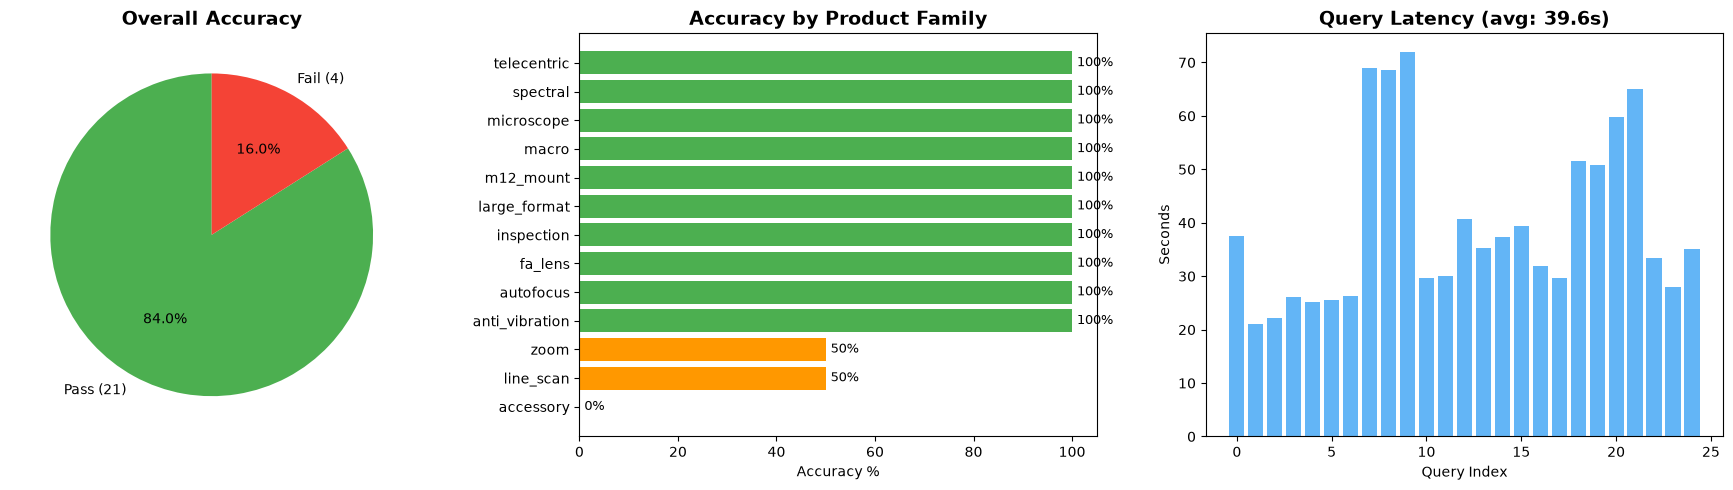

📁 Saved: evaluation_charts.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("evaluation_report.csv")

# Overall accuracy
passed = df["match"].sum()
failed = len(df) - passed
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart
axes[0].pie([passed, failed], labels=[f"Pass ({passed})", f"Fail ({failed})"],
            colors=["#4CAF50", "#f44336"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("Overall Accuracy", fontsize=14, fontweight="bold")

# Per-family bar chart
family_stats = df.groupby("product_family")["match"].agg(["sum", "count"])
family_stats["accuracy"] = family_stats["sum"] / family_stats["count"] * 100
family_stats = family_stats.sort_values("accuracy")
colors = ["#4CAF50" if a == 100 else "#FF9800" if a >= 50 else "#f44336" for a in family_stats["accuracy"]]
axes[1].barh(family_stats.index, family_stats["accuracy"], color=colors)
axes[1].set_xlim(0, 105)
axes[1].set_xlabel("Accuracy %")
axes[1].set_title("Accuracy by Product Family", fontsize=14, fontweight="bold")
for i, (idx, row) in enumerate(family_stats.iterrows()):
    axes[1].text(row["accuracy"] + 1, i, f"{row['accuracy']:.0f}%", va="center", fontsize=9)

# Timing
axes[2].bar(range(len(df)), df["elapsed_s"], color="#2196F3", alpha=0.7)
axes[2].set_xlabel("Query Index")
axes[2].set_ylabel("Seconds")
axes[2].set_title(f"Query Latency (avg: {df['elapsed_s'].mean():.1f}s)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("evaluation_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"📁 Saved: evaluation_charts.png")



In [5]:
# Download results
import pandas as pd


df.to_csv("evaluation_report.csv", index=False)
print("Saved!")

Saved!
